# Evaluation and error analysis

Load the saved **TF-IDF vectorizer** and **best classifier**, reproduce the **same train/test split** as training (`random_state=42`, `test_size=0.2`), then:

- **`classification_report`** — precision, recall, F1 (macro / weighted / per class)
- **Confusion matrix** — counts and heatmap (saved as PNG)
- **F1 per class** — extracted from the report for a clear table
- **Misclassified samples** — inspect original tweet text and cleaned text where predictions disagree with labels

**Prerequisites:** run `feature_extraction.ipynb` then `model_training.ipynb` so `models/tfidf_vectorizer.pkl` and `models/best_model.pkl` exist.

In [1]:
%pip install -q pandas scikit-learn scipy joblib matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name in {"notebooks", "notebook_runs"} else NOTEBOOK_DIR
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"

PROCESSED_CSV = DATA_DIR / "processed_dataset.csv"
VECTORIZER_PATH = MODELS_DIR / "tfidf_vectorizer.pkl"
BEST_MODEL_PATH = MODELS_DIR / "best_model.pkl"
REPORT_PATH = DATA_DIR / "classification_report.txt"
CONFUSION_PNG = NOTEBOOK_DIR / "confusion_matrix.png"

RANDOM_STATE = 42
TEST_SIZE = 0.20
CLASS_NAMES = ["negative", "neutral", "positive"]

In [3]:
if not VECTORIZER_PATH.is_file():
    raise FileNotFoundError(f"Missing {VECTORIZER_PATH} — run feature_extraction.ipynb first.")
if not BEST_MODEL_PATH.is_file():
    raise FileNotFoundError(f"Missing {BEST_MODEL_PATH} — run model_training.ipynb first.")

df = pd.read_csv(PROCESSED_CSV)
df = df.dropna(subset=["text_clean", "target"])
df["text_clean"] = df["text_clean"].astype(str).str.strip()
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)

y = df["target"].astype(int)
if not set(y.unique()).issubset({0, 1, 2}):
    raise ValueError("Expected target in {0,1,2}.")

train_df, test_df, _, y_test = train_test_split(
    df,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

vectorizer = joblib.load(VECTORIZER_PATH)
model = joblib.load(BEST_MODEL_PATH)

X_test = vectorizer.transform(test_df["text_clean"])
y_pred = model.predict(X_test)

print("Test set size:", len(test_df))

Test set size: 900


In [4]:
report_str = classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)
print(report_str)

REPORT_PATH.write_text(report_str, encoding="utf-8")
print("Saved:", REPORT_PATH)

              precision    recall  f1-score   support

    negative     1.0000    1.0000    1.0000       300
     neutral     1.0000    1.0000    1.0000       300
    positive     1.0000    1.0000    1.0000       300

    accuracy                         1.0000       900
   macro avg     1.0000    1.0000    1.0000       900
weighted avg     1.0000    1.0000    1.0000       900

Saved: D:\ml project\Social media and sentiment analysis\data\classification_report.txt


In [5]:
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

skip = {"accuracy", "macro avg", "weighted avg"}
f1_rows = []
for name, stats in report_dict.items():
    if name in skip or not isinstance(stats, dict):
        continue
    f1_rows.append(
        {
            "class": name,
            "precision": stats["precision"],
            "recall": stats["recall"],
            "f1": stats["f1-score"],
            "support": int(stats["support"]),
        }
    )

f1_per_class = pd.DataFrame(f1_rows)
display(f1_per_class)

print(
    "Macro F1:", round(report_dict["macro avg"]["f1-score"], 4),
    "| Weighted F1:", round(report_dict["weighted avg"]["f1-score"], 4),
)

,class,precision,recall,f1,support
0,negative,1.0,1.0,1.0,300
1,neutral,1.0,1.0,1.0,300
2,positive,1.0,1.0,1.0,300


Macro F1: 1.0 | Weighted F1: 1.0


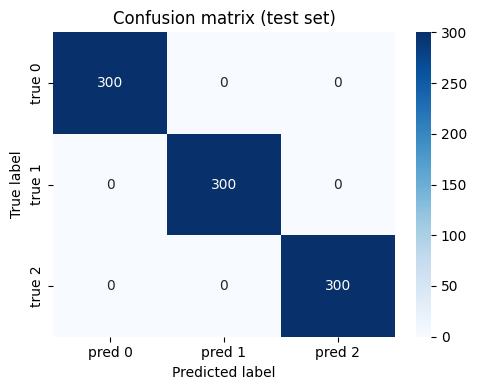

Saved: D:\ml project\Social media and sentiment analysis\notebooks\confusion_matrix.png


In [6]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred 0", "pred 1", "pred 2"],
    yticklabels=["true 0", "true 1", "true 2"],
    ax=ax,
)
ax.set_title("Confusion matrix (test set)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(CONFUSION_PNG, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", CONFUSION_PNG)

In [7]:
errors = test_df.copy()
errors["y_true"] = y_test.values
errors["y_pred"] = y_pred
errors = errors[errors["y_true"] != errors["y_pred"]].copy()
errors["true_label"] = errors["y_true"].map(
    {0: "negative", 1: "neutral", 2: "positive"}
)
errors["pred_label"] = errors["y_pred"].map(
    {0: "negative", 1: "neutral", 2: "positive"}
)

cols = [c for c in ["text", "text_clean", "true_label", "pred_label"] if c in errors.columns]
mis = errors[cols].head(25)

print(f"Misclassified: {len(errors)} / {len(test_df)} test examples")
display(mis)

Misclassified: 0 / 900 test examples


,text,text_clean,true_label,pred_label
